# High-Pass Filter Implementation

This notebook demonstrates the use of Ideal, Butterworth, and Gaussian high-pass filters applied to a grayscale image in the frequency domain. The following steps address various parts of the question:
- (2a) Compare Ideal, Butterworth, and Gaussian high-pass filters.
- (2b) Demonstrate the ringing effect for the Ideal high-pass filter.
- (2c) Compare Butterworth high-pass filters for different cutoff frequencies.
- (2d) Compare Gaussian high-pass filters for different cutoff frequencies.

## Step 1: Import libraries and load the image


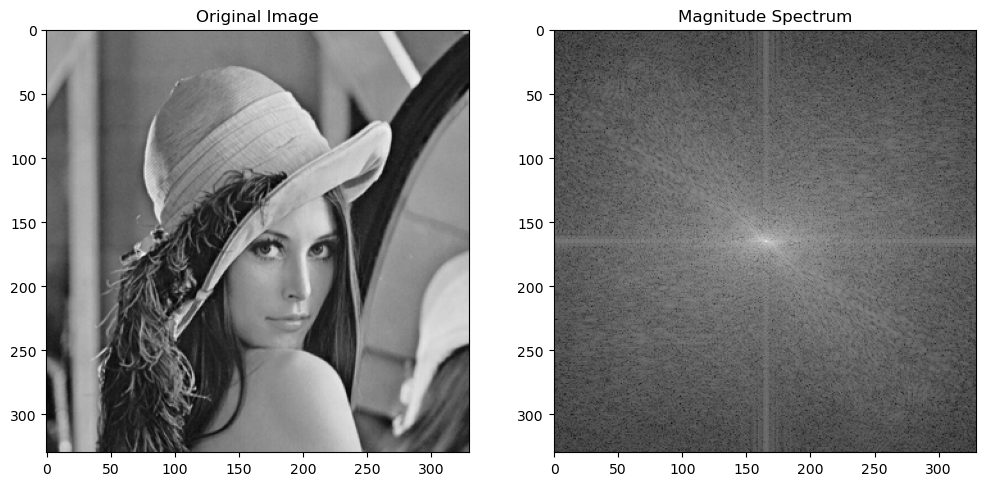

In [24]:

# Required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, ifft2, ifftshift

# Load the image (grayscale)
img = cv2.imread(r"E:\SRM\Digital Image\Lab 6 - 14th October\test_image.png", 0)

# Fourier Transform
f_transform = fft2(img)
f_transform_shifted = fftshift(f_transform)
magnitude_spectrum = np.log(np.abs(f_transform_shifted) + 1)

# Display the original image and its Fourier Transform
plt.figure(figsize=(12,6))
plt.subplot(1,2,1), plt.imshow(img, cmap='gray'), plt.title("Original Image")
plt.subplot(1,2,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title("Magnitude Spectrum")
plt.show()


## Step 2: Define High-Pass Filter Functions (Ideal, Butterworth, Gaussian)

In [26]:

# Ideal High-Pass Filter
def ideal_high_pass_filter(shape, D0):
    M, N = shape
    U, V = np.meshgrid(np.arange(M), np.arange(N), indexing='ij')
    D = np.sqrt((U - M/2)**2 + (V - N/2)**2)
    H = np.where(D > D0, 1, 0).astype(np.float32)
    return H

# Butterworth High-Pass Filter
# def butterworth_high_pass_filter(shape, D0, n):
#     M, N = shape
#     U, V = np.meshgrid(np.arange(M), np.arange(N), indexing='ij')
#     D = np.sqrt((U - M/2)**2 + (V - N/2)**2)
#     H = 1 / (1 + (D0 / D) ** (2 * n)).astype(np.float32)
#     return H

# RuntimeWarning: divide by zero encountered in divide, occurs because in the expression (D0 / D), 
# there might be some points in the frequency domain where D = 0. This happens at the center of the 
# frequency domain (DC component), where the distance is zero.
# To fix this issue, you can avoid division by zero by adding a small value (epsilon) to the 
# denominator or handling the center frequency separately.


def butterworth_high_pass_filter(shape, D0, n):
    M, N = shape
    H = np.zeros((M, N), dtype=np.float32)
    epsilon = 1e-5  # Small value to avoid division by zero
    for u in range(M):
        for v in range(N):
            D = np.sqrt((u - M / 2) ** 2 + (v - N / 2) ** 2)
            if D == 0:  # Handle the center (DC component)
                H[u, v] = 0
            else:
                H[u, v] = 1 / (1 + (D0 / (D + epsilon)) ** (2 * n))  # Avoid zero in the denominator
    return H

# Gaussian High-Pass Filter
def gaussian_high_pass_filter(shape, D0):
    M, N = shape
    U, V = np.meshgrid(np.arange(M), np.arange(N), indexing='ij')
    D = np.sqrt((U - M/2)**2 + (V - N/2)**2)
    H = 1 - np.exp(-(D ** 2) / (2 * (D0 ** 2))).astype(np.float32)
    return H


## Step 3: Define Helper Functions for Applying the Filter and Plotting Results

In [28]:

# Apply a filter and perform inverse Fourier Transform
def apply_filter_and_inverse(f_transform_shifted, H):
    Gshift = f_transform_shifted * H
    G = ifftshift(Gshift)
    g = np.abs(ifft2(G))
    return g

# Plotting function to compare original and filtered image
def plot_images(original, filtered, title):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(filtered, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


## Step 4: (2a) Compare Ideal, Butterworth, and Gaussian High-Pass Filters

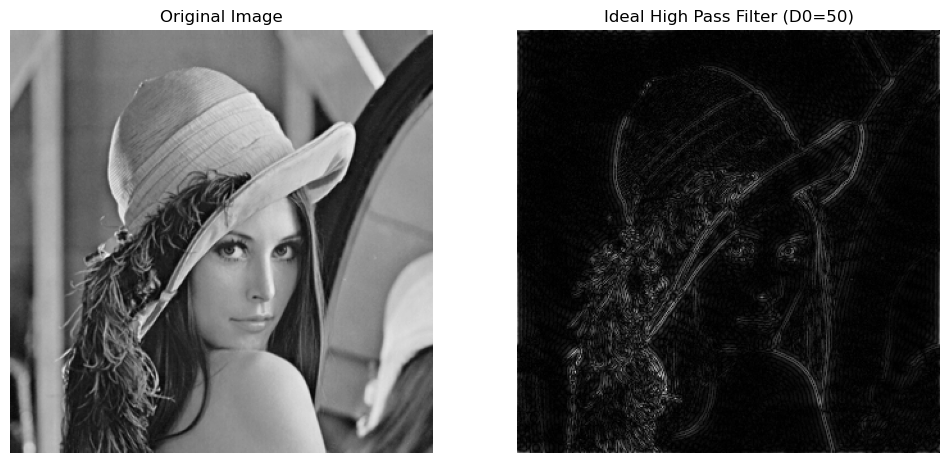

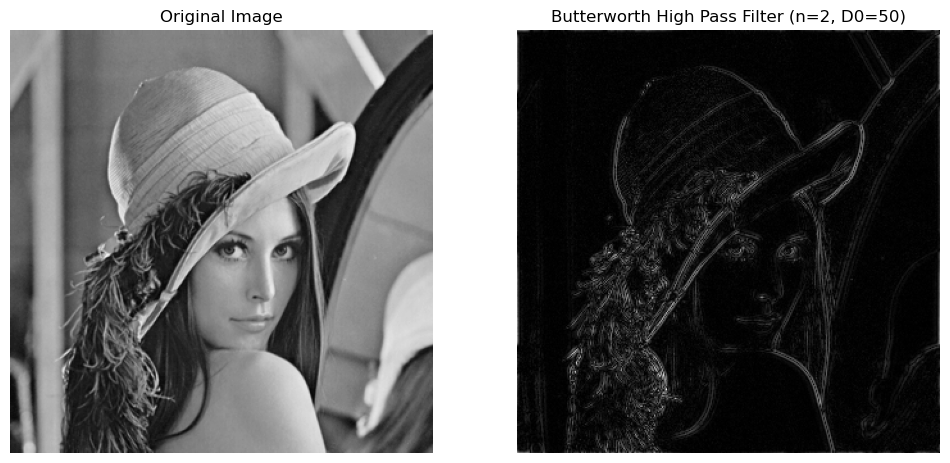

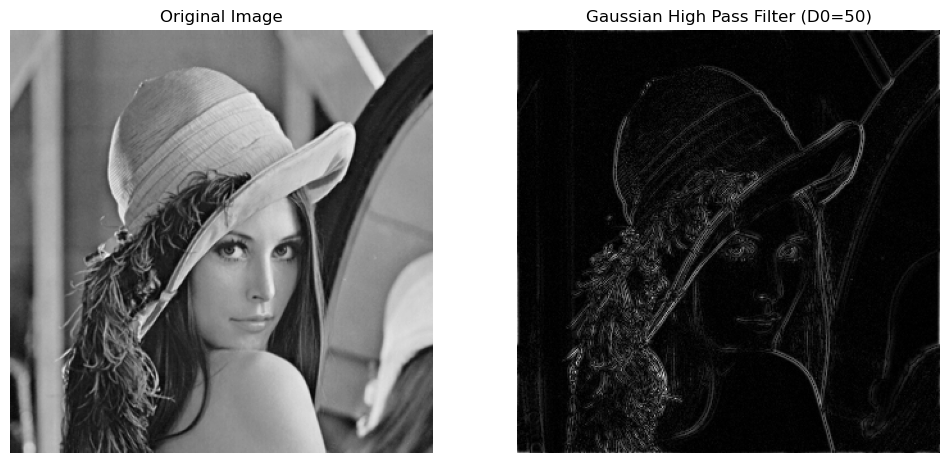

In [30]:

# Set cutoff frequency
cutoff = 50

# Ideal High-Pass Filter
H_ideal = ideal_high_pass_filter(img.shape, cutoff)
ideal_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_ideal)
plot_images(img, ideal_filtered_img, f"Ideal High Pass Filter (D0={cutoff})")

# Butterworth High-Pass Filter (Order 2)
n = 2
H_butterworth = butterworth_high_pass_filter(img.shape, cutoff, n)
butterworth_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_butterworth)
plot_images(img, butterworth_filtered_img, f"Butterworth High Pass Filter (n={n}, D0={cutoff})")

# Gaussian High-Pass Filter
H_gaussian = gaussian_high_pass_filter(img.shape, cutoff)
gaussian_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_gaussian)
plot_images(img, gaussian_filtered_img, f"Gaussian High Pass Filter (D0={cutoff})")


## Step 5: (2b) Demonstrate Ringing Effect on Ideal High-Pass Filter

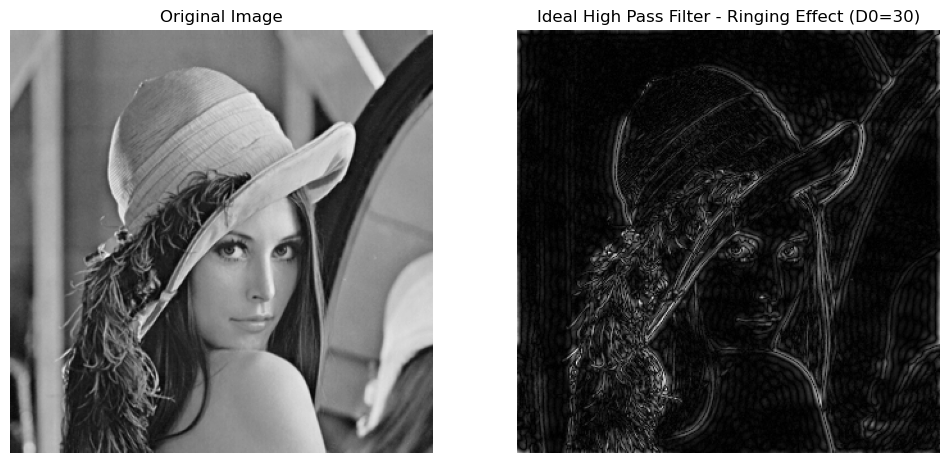

In [32]:

# Apply Ideal High-Pass Filter with ringing effect demonstration
cutoff = 30  # Sharp cut-off frequency to highlight ringing
H_ideal_ringing = ideal_high_pass_filter(img.shape, cutoff)
ideal_filtered_img_ringing = apply_filter_and_inverse(f_transform_shifted, H_ideal_ringing)
plot_images(img, ideal_filtered_img_ringing, f"Ideal High Pass Filter - Ringing Effect (D0={cutoff})")


## Step 6: (2c) Compare Butterworth High-Pass Filters for Different Cutoff Frequencies

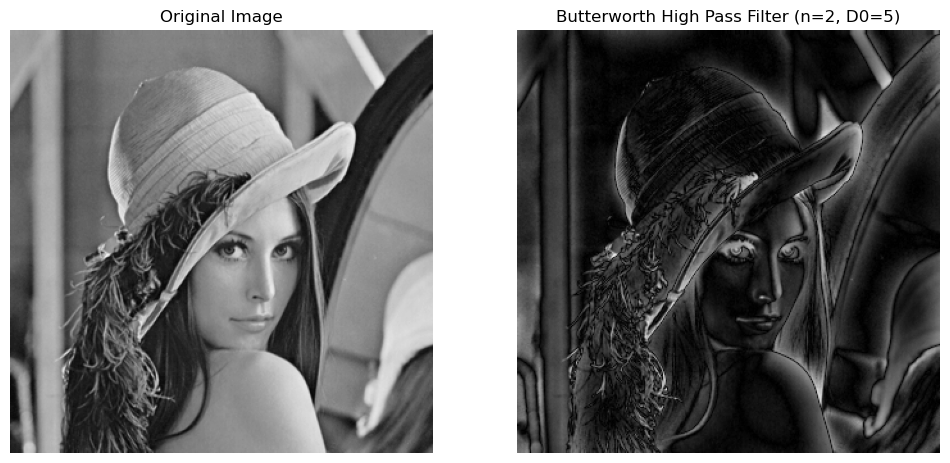

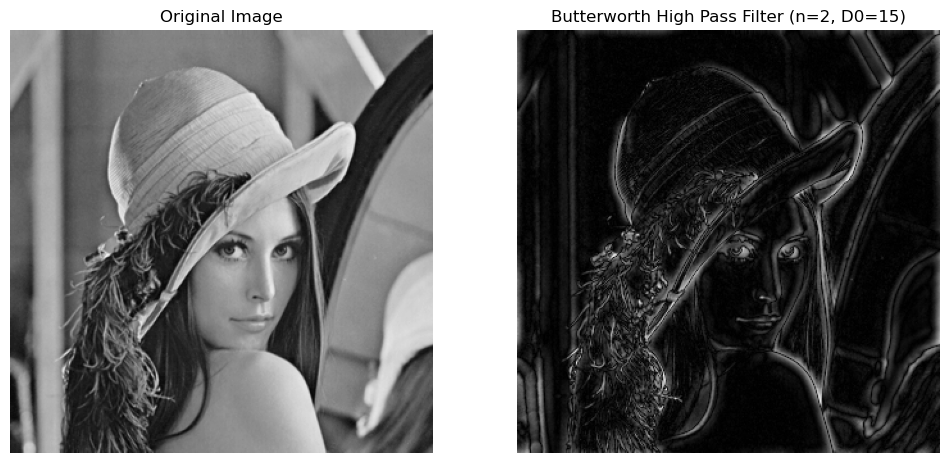

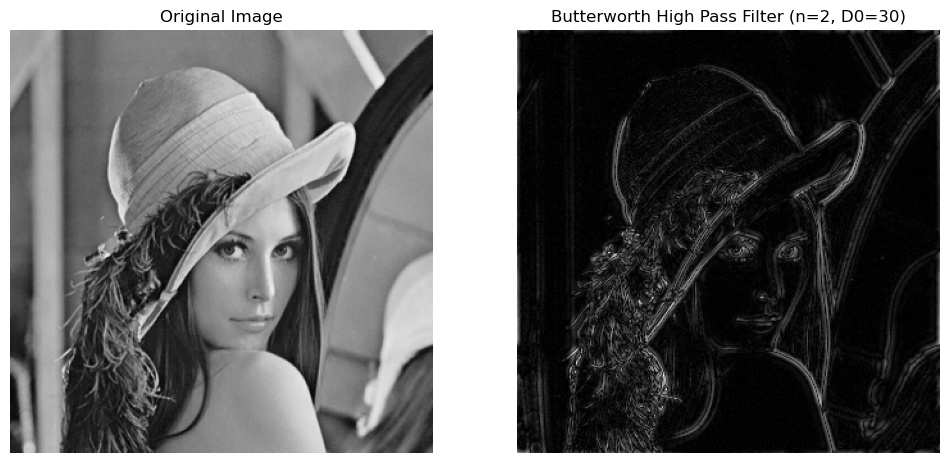

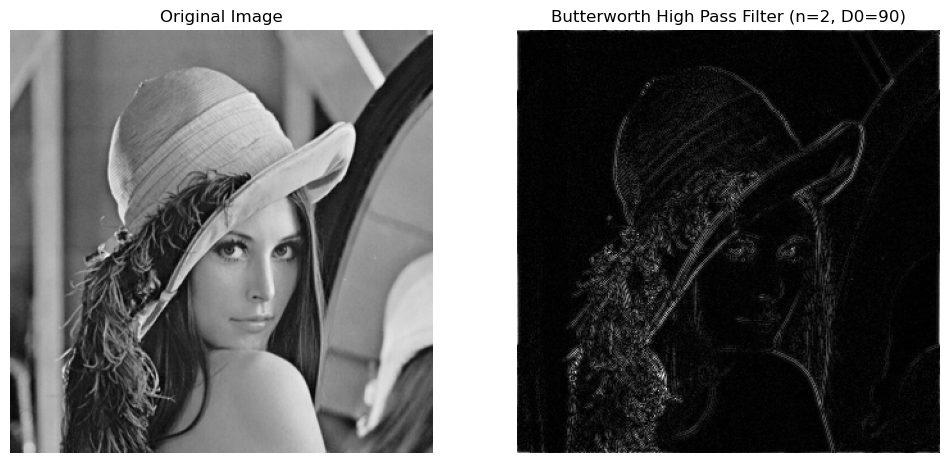

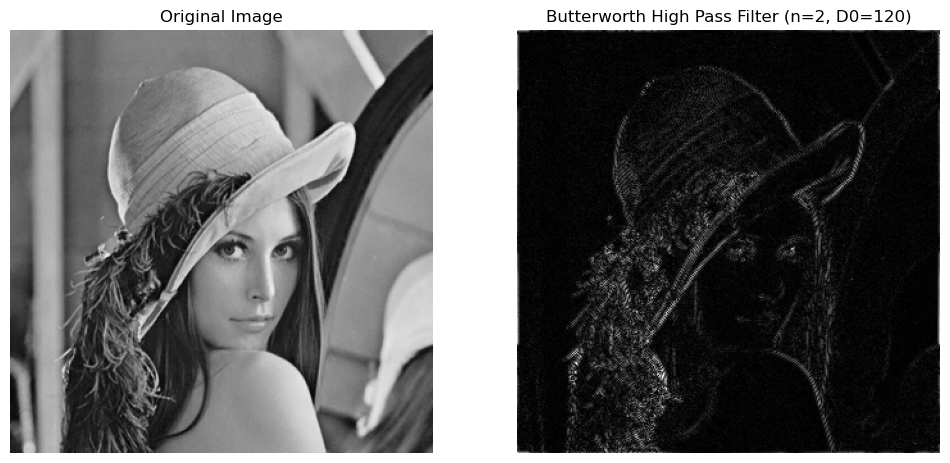

In [34]:

# Compare Butterworth High-Pass Filters for different cutoff frequencies
cutoffs = [5, 15, 30, 90, 120]
n = 2  # Fixed order of the filter

for c in cutoffs:
    H_butterworth = butterworth_high_pass_filter(img.shape, c, n)
    butterworth_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_butterworth)
    plot_images(img, butterworth_filtered_img, f"Butterworth High Pass Filter (n={n}, D0={c})")


## Step 7: (2d) Compare Gaussian High-Pass Filters for Different Cutoff Frequencies

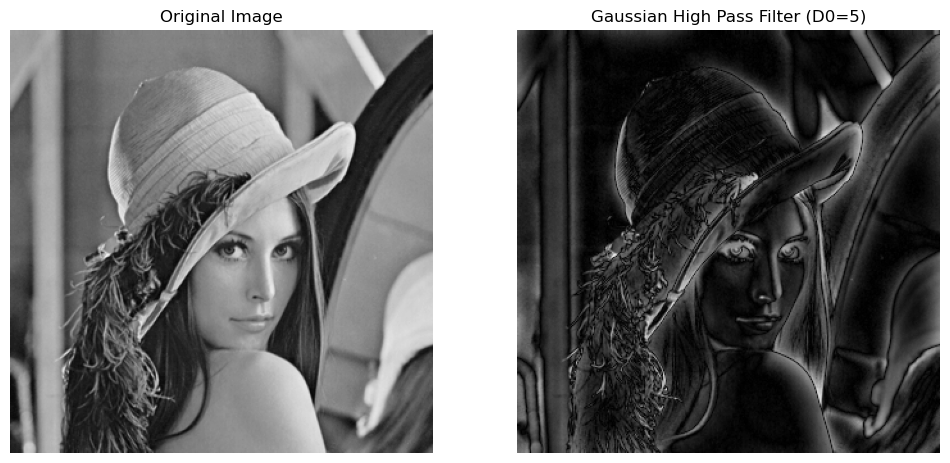

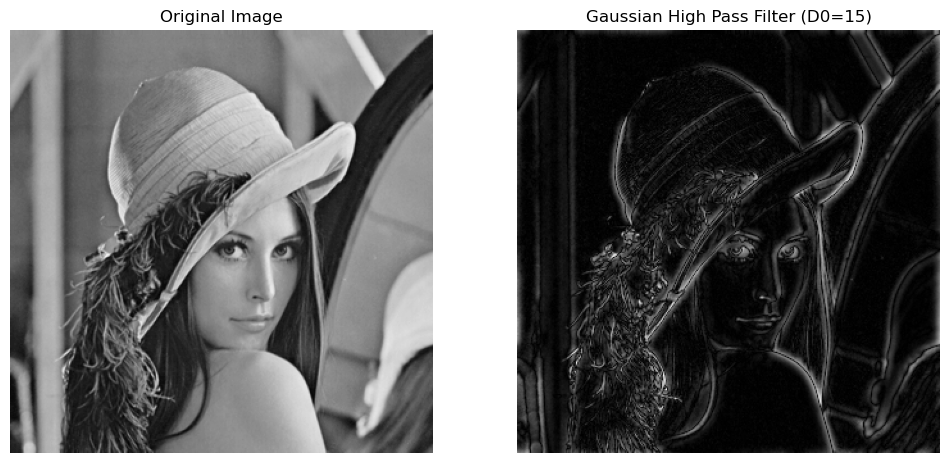

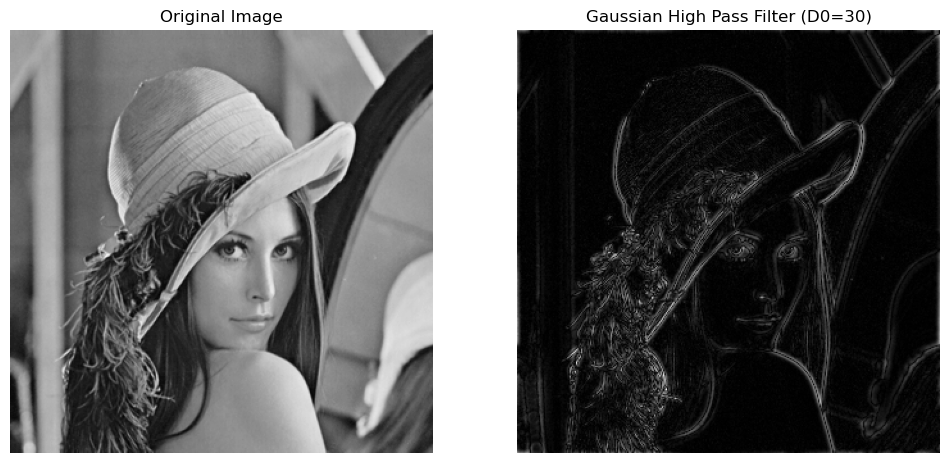

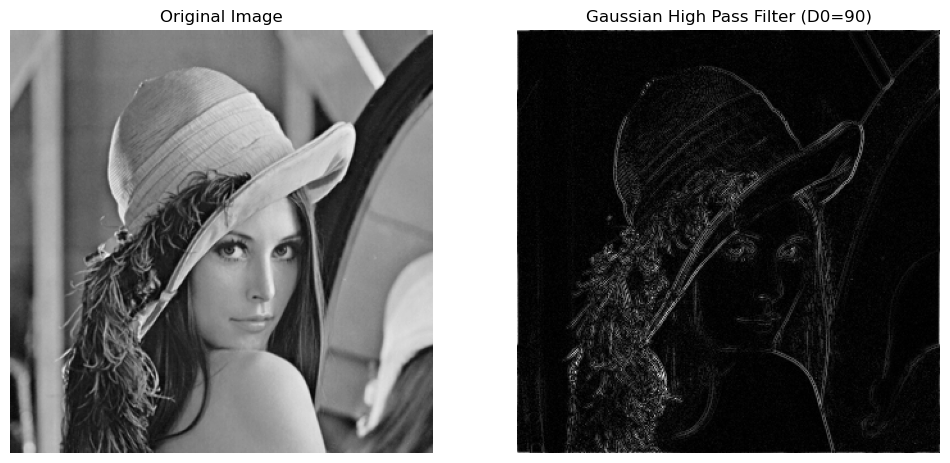

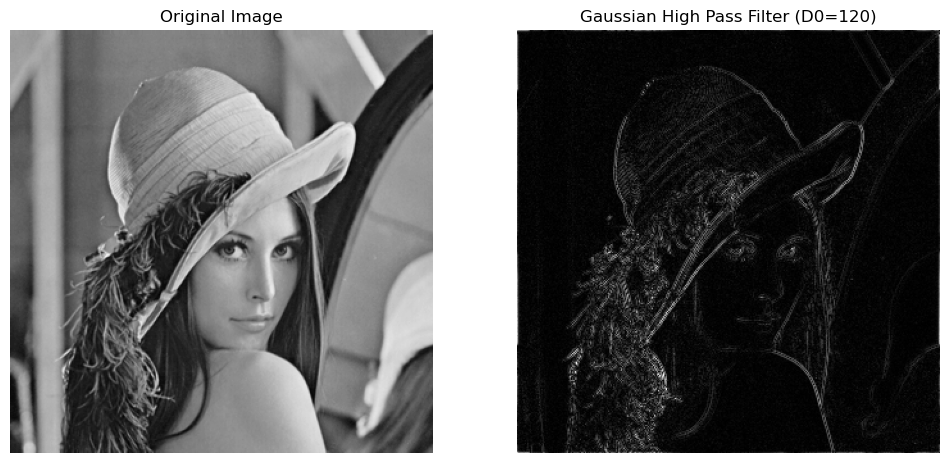

In [36]:

# Compare Gaussian High-Pass Filters for different cutoff frequencies
cutoffs = [5, 15, 30, 90, 120]

for c in cutoffs:
    H_gaussian = gaussian_high_pass_filter(img.shape, c)
    gaussian_filtered_img = apply_filter_and_inverse(f_transform_shifted, H_gaussian)
    plot_images(img, gaussian_filtered_img, f"Gaussian High Pass Filter (D0={c})")
